In [ ]:
import imfusion as imf
from imfusion import vision
import numpy as np
from matplotlib import pyplot as plt
import pathlib


## a. Load stereo image pair with camera calibration

In [8]:
# Load left image and attach camera calibration information.
left_image_path = pathlib.Path("data/stereo_left.png")
left_image = imf.load(str(left_image_path))[0]

left_image_calib = vision.CameraCalibrationDataComponent()
left_fx = 1625.408; left_fy = 1625.408; left_cx = 199.345; left_cy = 240.165
left_image_calib.intrinsic_matrix = np.array([
    [left_fx, 0, left_cx],
    [0, left_fy, left_cy],
    [0, 0, 1]
])
left_image_calib.distortion = np.array([0.0]*5) # k1, k2, p1, p2, k3
left_image_calib.image_size = np.array([left_image[0].width, left_image[0].height])
added_component = left_image.components.add(left_image_calib)

# Now do the same for right image
right_image_path = pathlib.Path("data/stereo_right.png")
right_image = imf.load(str(right_image_path))[0]

right_image_calib = vision.CameraCalibrationDataComponent()
right_fx = 1625.408; right_fy = 1625.408; right_cx = 284.364; right_cy = 240.165
right_image_calib.intrinsic_matrix = np.array([
    [right_fx, 0, right_cx],
    [0, right_fy, right_cy],
    [0, 0, 1]
])
right_image_calib.distortion = np.array([0.0]*5) # k1, k2, p1, p2, k3
right_image_calib.image_size = np.array([right_image[0].width, right_image[0].height])
# Also add information of right camera pose w.r.t. the left camera. 
right_image_calib.registration = np.array([
    [1, 0, 0, 169.84],  
    [0, 1, 0, 0],  
    [0, 0, 1, 0],  
    [0, 0, 0, 1]])

added_component = right_image.components.add(right_image_calib)

## b. Reconstruction

In [ ]:
# Choose stereo reconstruction algorithm:
# params = vision.stereo.BlockMatchingParameters() # Block matching
# params = vision.stereo.SemiGlobalBlockMatchingParameters() # Semi Global Block matching
# params = vision.stereo.StereoCGIParameters() # Machine learning approach from https://arxiv.org/abs/2301.02789
params = vision.stereo.StereoRAFTParameters() # Machine learning approach from https://arxiv.org/abs/2109.07547
# params = vision.stereo.StereoRAFTParameters(use_smaller_model=True) # Use smaller (and faster) version of the above ML model but with possibly lower accuracy. 
reconstruction_result = vision.stereo.stereo_reconstruction(left_image, right_image, reconstruction_parameters=params)

## c. Visualize outputs


#### Visualize depth and disparity

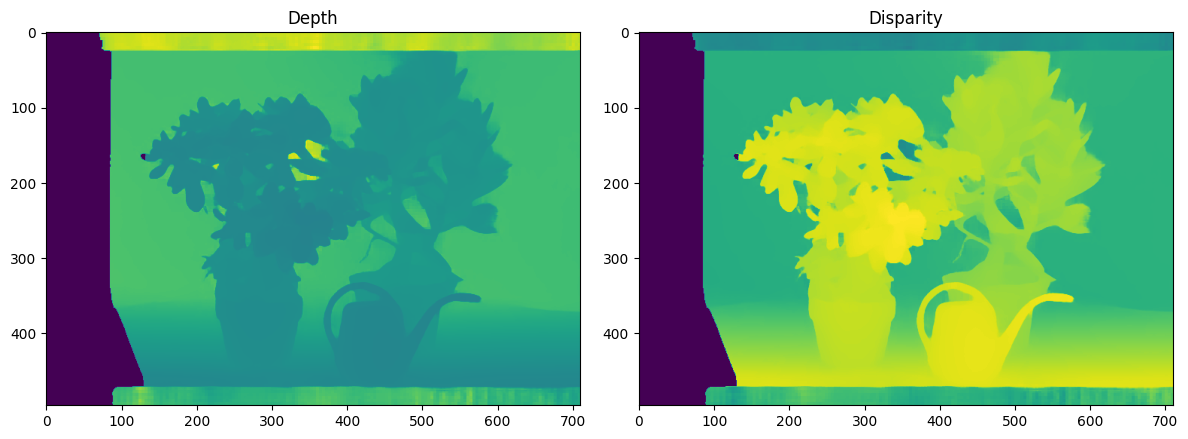

In [10]:
disparity_np = reconstruction_result.disparity.numpy() # [num_images, H, W, 1]
depth_np = reconstruction_result.depth.numpy() # [num_images, H, W, 1]
pointclouds = reconstruction_result.point_clouds # [num_images]

depth_vis = depth_np.squeeze((0, 3)) # [H, W]
disparity_vis = disparity_np.squeeze((0, 3)) # [H, W]

# Show depth and disparities
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(depth_vis, cmap='viridis')
axes[0].set_title('Depth')
axes[1].imshow(disparity_vis, cmap='viridis')
axes[1].set_title('Disparity')
plt.tight_layout()
plt.show()

#### Visualize reconstructed point cloud

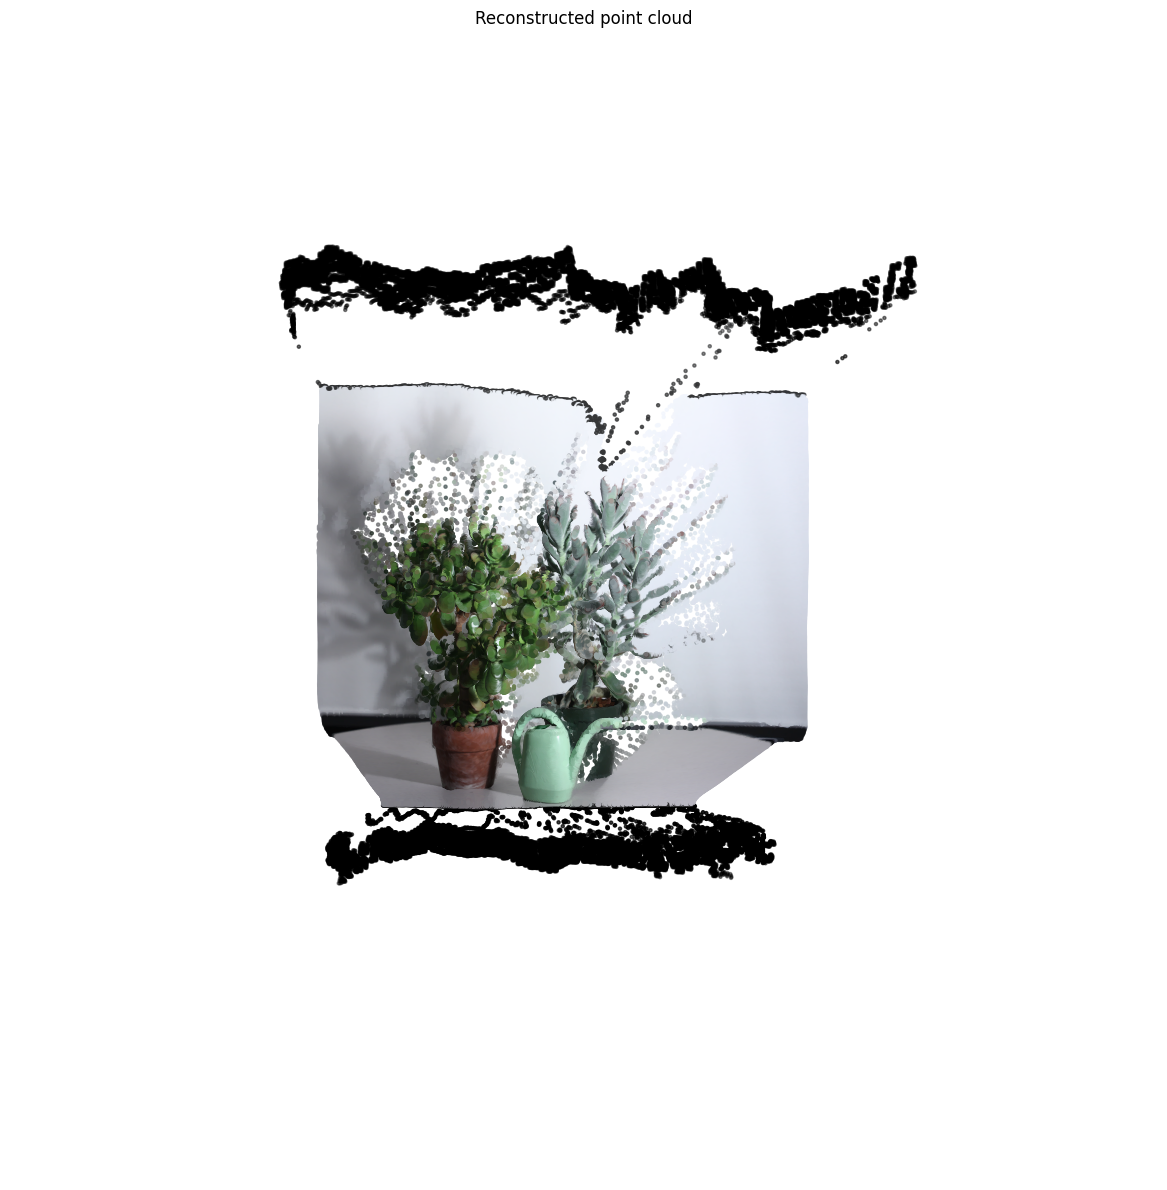

In [15]:

points_np = np.array(pointclouds[0].points) # [num_points, 3]
colors_np = np.array(pointclouds[0].colors) # [num_points, 3]
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

x = points_np[:, 0]
y = points_np[:, 1]
z = points_np[:, 2]

# Plot with actual RGB colors
ax.scatter(x, y, z, c=colors_np, s=5)

ax.set_title('Reconstructed point cloud')
ax.view_init(elev=-80, azim=-90)
plt.axis('off')
plt.tight_layout()
plt.show()